In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train, _), (X_test, _) = tf.keras.datasets.cifar10.load_data()

In [3]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [ ]:
input_img = Input(shape=(32, 32, 3))

# --- Encoder ---
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# --- Decoder ---
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x) 

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [19]:
autoencoder.fit(X_train, X_train,
                epochs=5,
                batch_size=128,
                shuffle=True,
                validation_data=(X_test, X_test))

# Predict
decoded_imgs = autoencoder.predict(X_test[:10])

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.6326 - val_loss: 0.5900
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.5880 - val_loss: 0.5853
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.5842 - val_loss: 0.5832
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.5827 - val_loss: 0.5821
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.5809 - val_loss: 0.5810
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


In [20]:
# Get compressed (encoded) representations
encoder = Model(inputs=input_img, outputs=encoded)
encoded_imgs = encoder.predict(X_test)

# Print original and compressed shapes for one image
original_shape = X_test[0].shape
compressed_shape = encoded_imgs[0].shape

print("Original image shape:", original_shape)
print("Compressed image shape:", compressed_shape)

# Print actual number of elements (bytes, sort of)
original_size = np.prod(original_shape)
compressed_size = np.prod(compressed_shape)

print("Original image size (pixels):", original_size)
print("Compressed image size (pixels):", compressed_size)
print("Compression ratio: {:.2f}x".format(original_size / compressed_size))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Original image shape: (32, 32, 3)
Compressed image shape: (4, 4, 8)
Original image size (pixels): 3072
Compressed image size (pixels): 128
Compression ratio: 24.00x


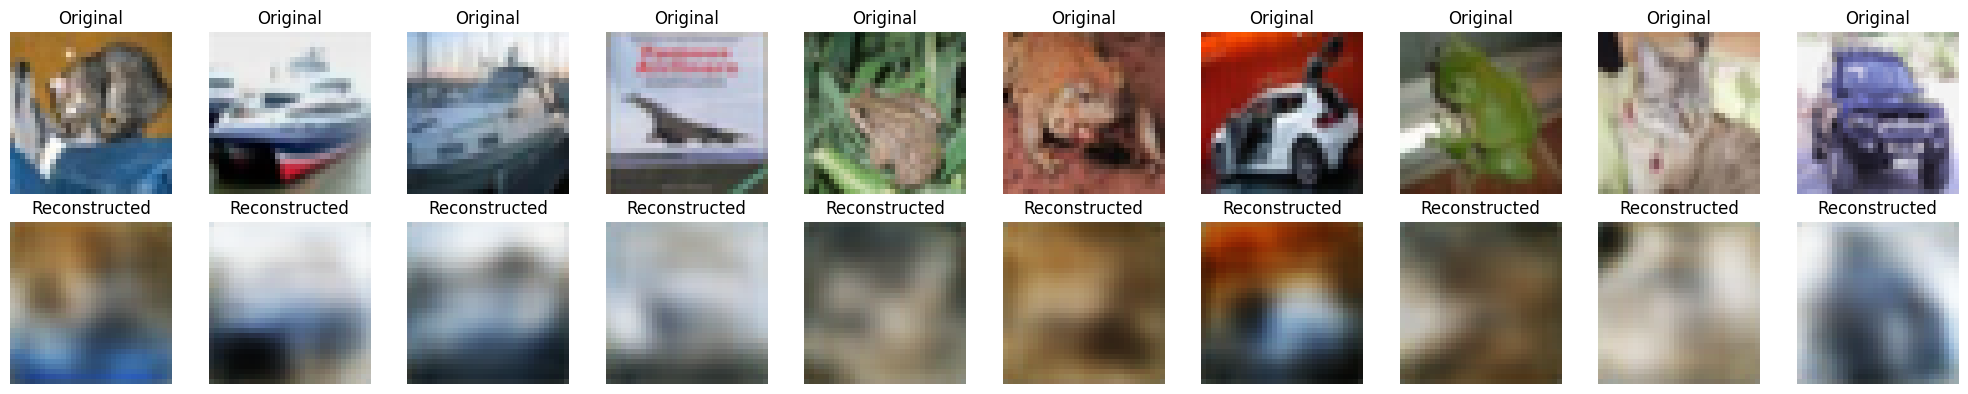

In [21]:
n = 10  # Number of images to display
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])  # No need to reshape
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])  # Already in (32, 32, 3)
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()